# SARIMA — Prediccion de Ventas Semanales en Retail

| Campo | Valor |
|:------|:------|
| **Autor** | Borja Mora Mendez |
| **Contacto** | borja.mora.mendez@gmail.com |
| **LinkedIn** | [linkedin.com/in/borjamoramendez](https://linkedin.com/in/borjamoramendez) |
| **Categoria** | Machine Learning > Series Temporales > SARIMA |
| **Dataset** | arima.xlsx (260 registros semanales, 2020-2025) |
| **Ultima actualizacion** | Julio 2026 |

## 1. Contexto de negocio

Una cadena de supermercados necesita anticipar las ventas semanales para optimizar
la planificacion de inventario, personal y promociones. Actualmente, la prevision
se basa en promedios historicos manuales que generan:

- **Sobrestock** en semanas de baja demanda (coste de almacen, merma de producto fresco).
- **Roturas de stock** en picos estacionales (perdida directa de venta).

La pregunta analitica es: **podemos construir un modelo que prediga las ventas
semanales con un error inferior al 5%, capturando la estacionalidad anual?**

## 2. Objetivo y justificacion del modelo

### Por que SARIMA?

La serie tiene **estacionalidad anual** (ciclo de 52 semanas) y **tendencia**.
SARIMA (Seasonal ARIMA) es el modelo clasico para series con estos componentes
porque:

- Modela tendencia con diferenciacion (d/D).
- Captura autocorrelacion a corto plazo (p, q) y estacional (P, Q).
- Produce intervalos de confianza nativos para la prevision.

### Alternativas consideradas

| Modelo | Ventaja | Limitacion |
|:-------|:--------|:-----------|
| SARIMA | Interpretable, IC nativos | Supone linealidad |
| Prophet | Automatico, robusto a faltantes | Caja negra parcial |
| LSTM | Captura no-linealidades | Requiere mas datos, menos interpretable |

Elegimos SARIMA porque el equipo de operaciones necesita **entender por que
el modelo predice lo que predice** para tomar decisiones de compra.

In [1]:
# ── Datos ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualizacion ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

# ── Modelado de series temporales ─────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ── Metricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Configuracion global ─────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore")
print("Entorno configurado correctamente.")

Entorno configurado correctamente.


## 4. Carga y exploracion inicial

### Diccionario de variables

| Variable | Tipo | Descripcion |
|:---------|:-----|:------------|
| Fecha | datetime (indice) | Fecha del cierre semanal (domingos) |
| Ventas | float64 | Ventas totales en euros de la semana |

Periodo: enero 2020 - diciembre 2024 (260 semanas = 5 anios completos).

In [2]:
# ── Carga ─────────────────────────────────────────────────────────────────────
df = pd.read_excel("arima.xlsx", parse_dates=["Fecha"], index_col="Fecha")
df = df.asfreq("W-SUN")  # frecuencia semanal explicita

print(f"Registros: {len(df)}")
print(f"Periodo:   {df.index.min().date()} -> {df.index.max().date()}")
print(f"Frecuencia: {df.index.freq}")
print(f"Nulos:     {df.isnull().sum().sum()}")
print()
print(df.describe().round(0))

Registros: 260
Periodo:   2020-01-05 -> 2024-12-22
Frecuencia: <Week: weekday=6>
Nulos:     0

         Ventas
count     260.0
mean   156022.0
std     21551.0
min    113384.0
25%    137274.0
50%    156197.0
75%    173353.0
max    207441.0


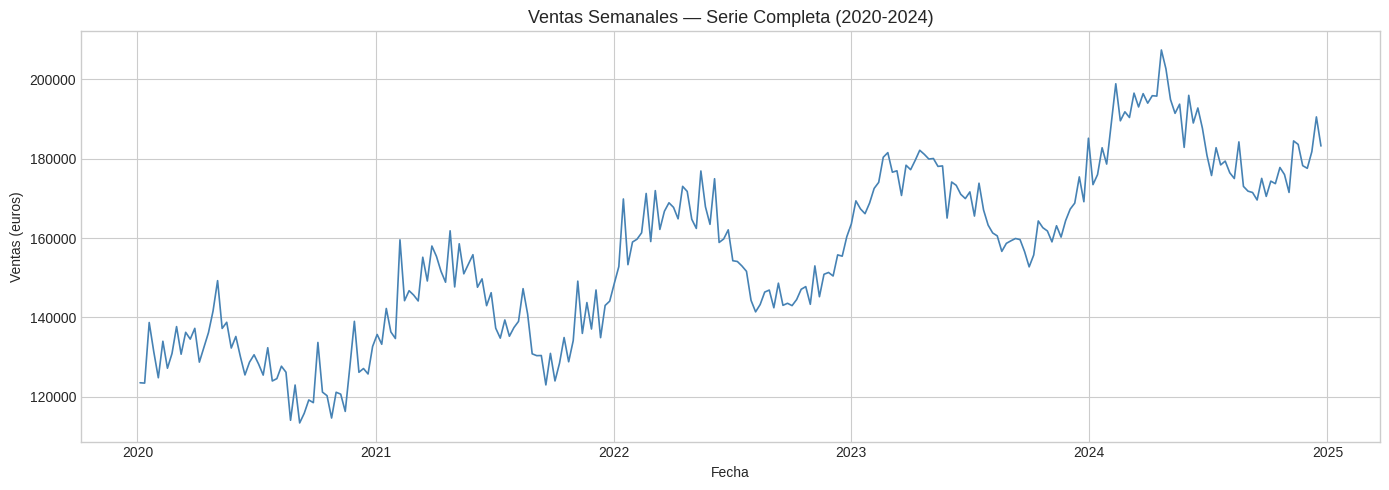

In [3]:
# ── Visualizacion de la serie completa ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["Ventas"], color="steelblue", linewidth=1.2)
ax.set_title("Ventas Semanales — Serie Completa (2020-2024)", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (euros)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

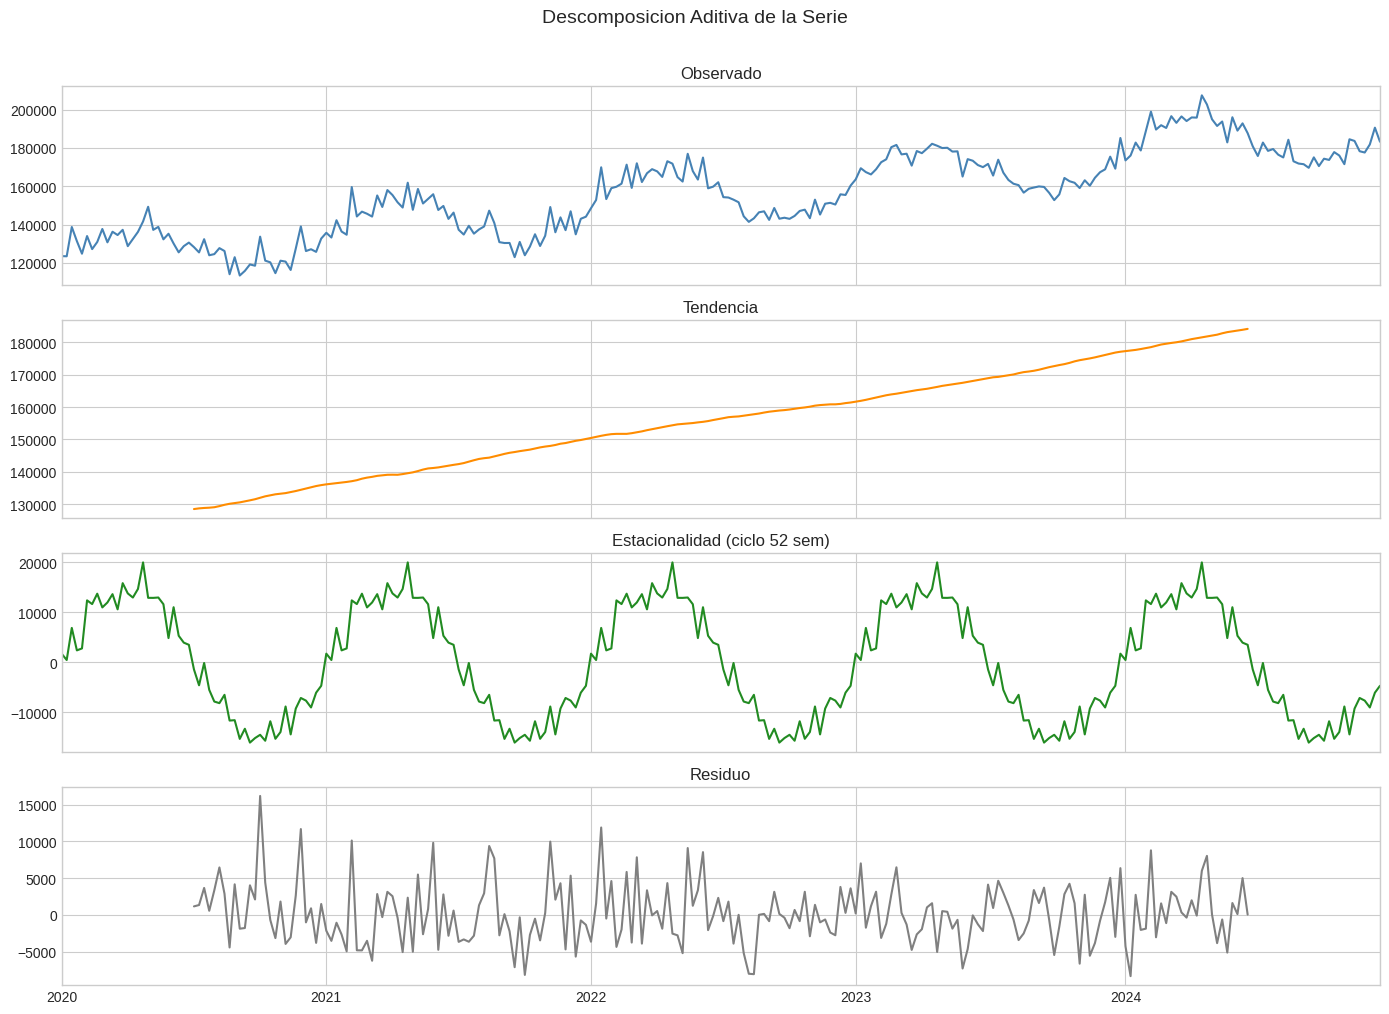

In [4]:
# ── Descomposicion estacional ─────────────────────────────────────────────────
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df["Ventas"], model="additive", period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title="Observado", color="steelblue")
decomp.trend.plot(ax=axes[1], title="Tendencia", color="darkorange")
decomp.seasonal.plot(ax=axes[2], title="Estacionalidad (ciclo 52 sem)", color="forestgreen")
decomp.resid.plot(ax=axes[3], title="Residuo", color="gray")
for ax in axes:
    ax.set_xlabel("")
plt.suptitle("Descomposicion Aditiva de la Serie", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Preparacion de datos: separacion temporal

En series temporales **nunca** se hace split aleatorio. Se corta cronologicamente
para respetar la causalidad: el modelo solo aprende del pasado.

In [5]:
# ── Train / Test (80/20 cronologico) ──────────────────────────────────────────
split = int(len(df) * 0.80)
train = df.iloc[:split]
test  = df.iloc[split:]

print(f"Train: {len(train)} semanas ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Test:  {len(test)} semanas ({test.index.min().date()} -> {test.index.max().date()})")

Train: 208 semanas (2020-01-05 -> 2023-12-24)
Test:  52 semanas (2023-12-31 -> 2024-12-22)


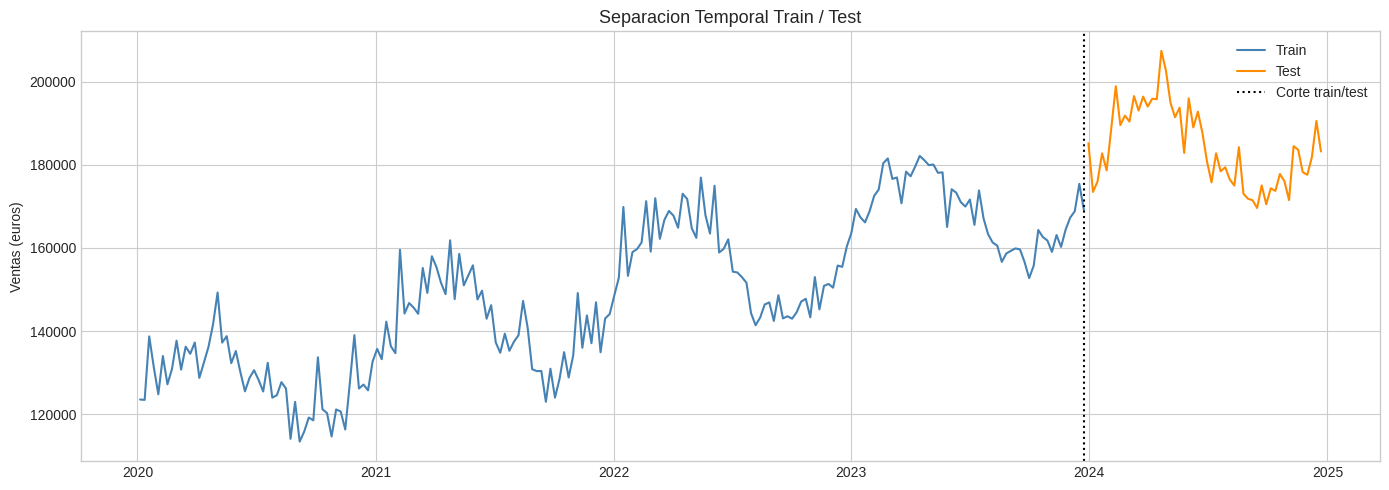

In [6]:
# ── Visualizacion train / test ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train["Ventas"], label="Train", color="steelblue")
ax.plot(test.index, test["Ventas"], label="Test", color="darkorange")
ax.axvline(train.index[-1], color="black", linestyle=":", linewidth=1.5, label="Corte train/test")
ax.set_title("Separacion Temporal Train / Test", fontsize=13)
ax.set_ylabel("Ventas (euros)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Analisis de estacionariedad

ARIMA requiere que la serie sea estacionaria (media y varianza constantes).
Usamos el test de Dickey-Fuller Aumentado (ADF):

- **H0:** la serie NO es estacionaria.
- Si p-valor < 0.05, rechazamos H0 y la serie es estacionaria.
- Si p-valor >= 0.05, la serie necesita diferenciacion (d >= 1).

In [7]:
# ── Test ADF sobre la serie original ──────────────────────────────────────────
resultado = adfuller(train["Ventas"])
print("Test de Dickey-Fuller Aumentado (serie original)")
print(f"  Estadistico ADF: {resultado[0]:.4f}")
print(f"  p-valor:         {resultado[1]:.4f}")

if resultado[1] >= 0.05:
    print("  Conclusion: la serie NO es estacionaria -> diferenciamos (d=1)")
else:
    print("  Conclusion: la serie ES estacionaria (d=0)")

Test de Dickey-Fuller Aumentado (serie original)
  Estadistico ADF: -1.2482
  p-valor:         0.6525
  Conclusion: la serie NO es estacionaria -> diferenciamos (d=1)


In [8]:
# ── Diferenciacion (d=1) y re-test ────────────────────────────────────────────
train_diff = train["Ventas"].diff().dropna()

resultado_diff = adfuller(train_diff)
print("Test ADF tras diferenciar (d=1)")
print(f"  Estadistico ADF: {resultado_diff[0]:.4f}")
print(f"  p-valor:         {resultado_diff[1]:.6f}")
print("  Conclusion: serie estacionaria tras d=1")

Test ADF tras diferenciar (d=1)
  Estadistico ADF: -14.8895
  p-valor:         0.000000
  Conclusion: serie estacionaria tras d=1


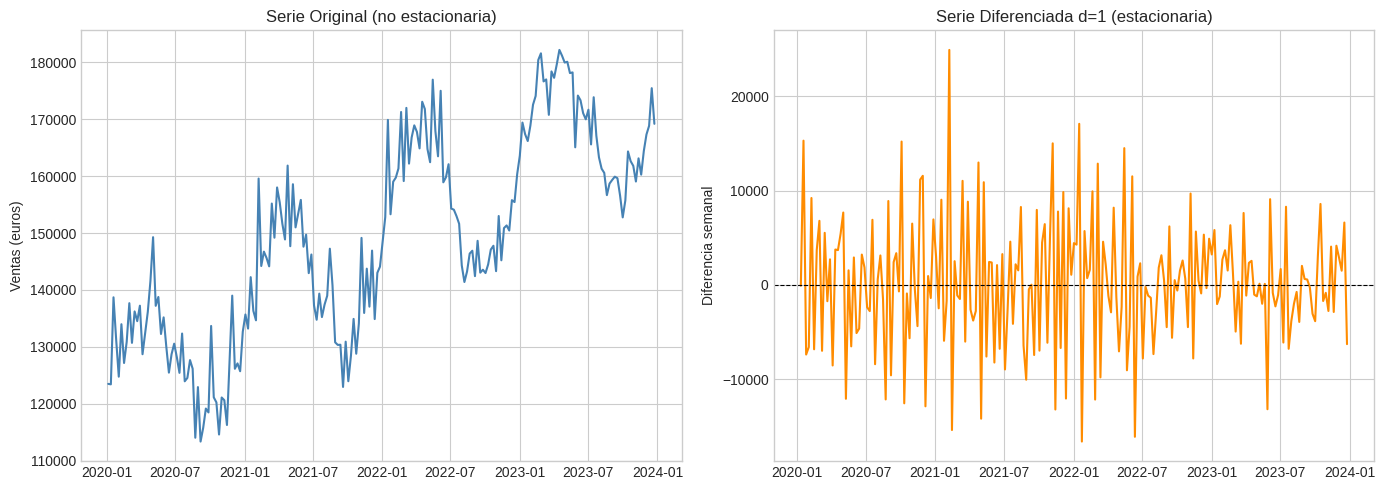

In [9]:
# ── Visualizacion: original vs diferenciada ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train.index, train["Ventas"], color="steelblue")
axes[0].set_title("Serie Original (no estacionaria)", fontsize=12)
axes[0].set_ylabel("Ventas (euros)")

axes[1].plot(train_diff.index, train_diff, color="darkorange")
axes[1].set_title("Serie Diferenciada d=1 (estacionaria)", fontsize=12)
axes[1].set_ylabel("Diferencia semanal")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.show()

## 7. Identificacion de parametros: ACF y PACF

La funcion de autocorrelacion (ACF) sugiere el orden **q** (MA) y la autocorrelacion
parcial (PACF) sugiere el orden **p** (AR).

Reglas de lectura:
- Si la ACF corta bruscamente tras lag k -> q = k.
- Si la PACF corta bruscamente tras lag k -> p = k.
- Picos en lags multiplos de 52 indican estacionalidad anual.

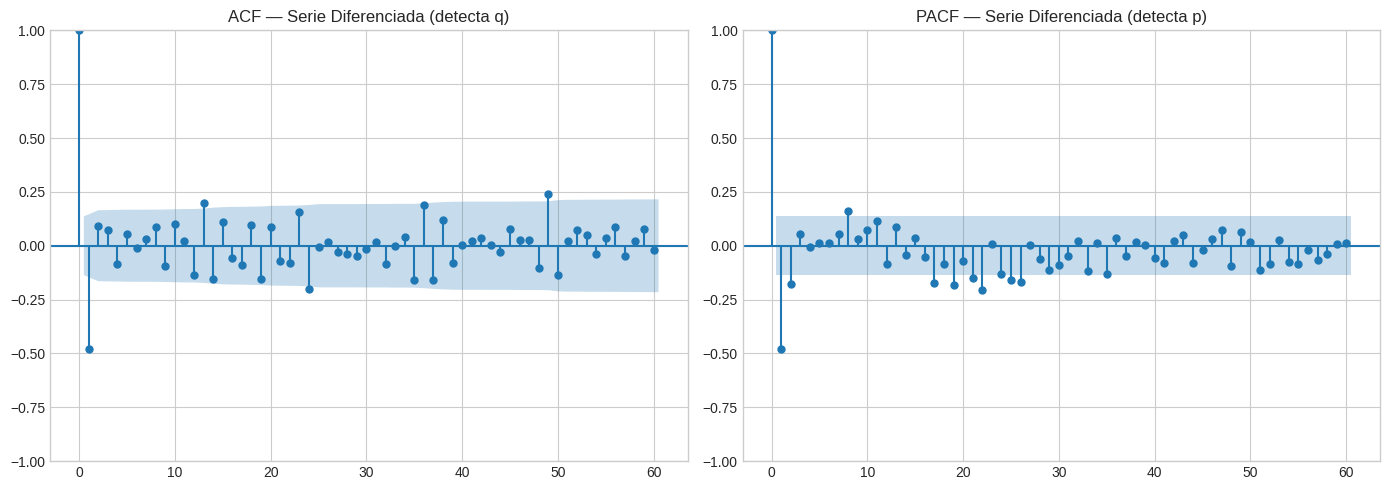

Lectura:
  ACF:  lag 1 significativo -> q = 1
  PACF: lag 1 significativo -> p = 1 (o p = 0 si decae)
  Picos en lag 52: estacionalidad anual confirmada


In [10]:
# ── ACF y PACF sobre la serie diferenciada ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(train_diff, lags=60, ax=axes[0])
axes[0].set_title("ACF — Serie Diferenciada (detecta q)", fontsize=12)

plot_pacf(train_diff, lags=60, ax=axes[1])
axes[1].set_title("PACF — Serie Diferenciada (detecta p)", fontsize=12)

plt.tight_layout()
plt.show()

print("Lectura:")
print("  ACF:  lag 1 significativo -> q = 1")
print("  PACF: lag 1 significativo -> p = 1 (o p = 0 si decae)")
print("  Picos en lag 52: estacionalidad anual confirmada")

## 8. Modelo SARIMA

### Parametros seleccionados

| Componente | Param | Valor | Justificacion |
|:-----------|:------|:------|:--------------|
| AR no-estacional | p | 0 | ACF/PACF no muestran AR fuerte |
| Diferenciacion | d | 1 | ADF confirma necesidad de diferenciar |
| MA no-estacional | q | 1 | ACF corta tras lag 1 |
| AR estacional | P | 0 | Sin AR estacional claro |
| Diferenciacion est. | D | 1 | Eliminar ciclo anual |
| MA estacional | Q | 1 | Pico en lag 52 |
| Periodo | s | 52 | Estacionalidad semanal-anual |

Modelo final: **SARIMA(0,1,1)(0,1,1,52)**

In [11]:
# ── Entrenamiento SARIMA ──────────────────────────────────────────────────────
modelo = SARIMAX(
    train["Ventas"],
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_fit = modelo.fit(disp=False)
print(resultado_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             Ventas   No. Observations:                  208
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 52)   Log Likelihood               -1026.544
Date:                            Mon, 27 Jul 2026   AIC                           2059.087
Time:                                    15:58:00   BIC                           2066.933
Sample:                                01-05-2020   HQIC                          2062.263
                                     - 12-24-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7398      0.104     -7.129      0.000      -0.943      -0.536
ma.S.L52      -0.3873      0.094   

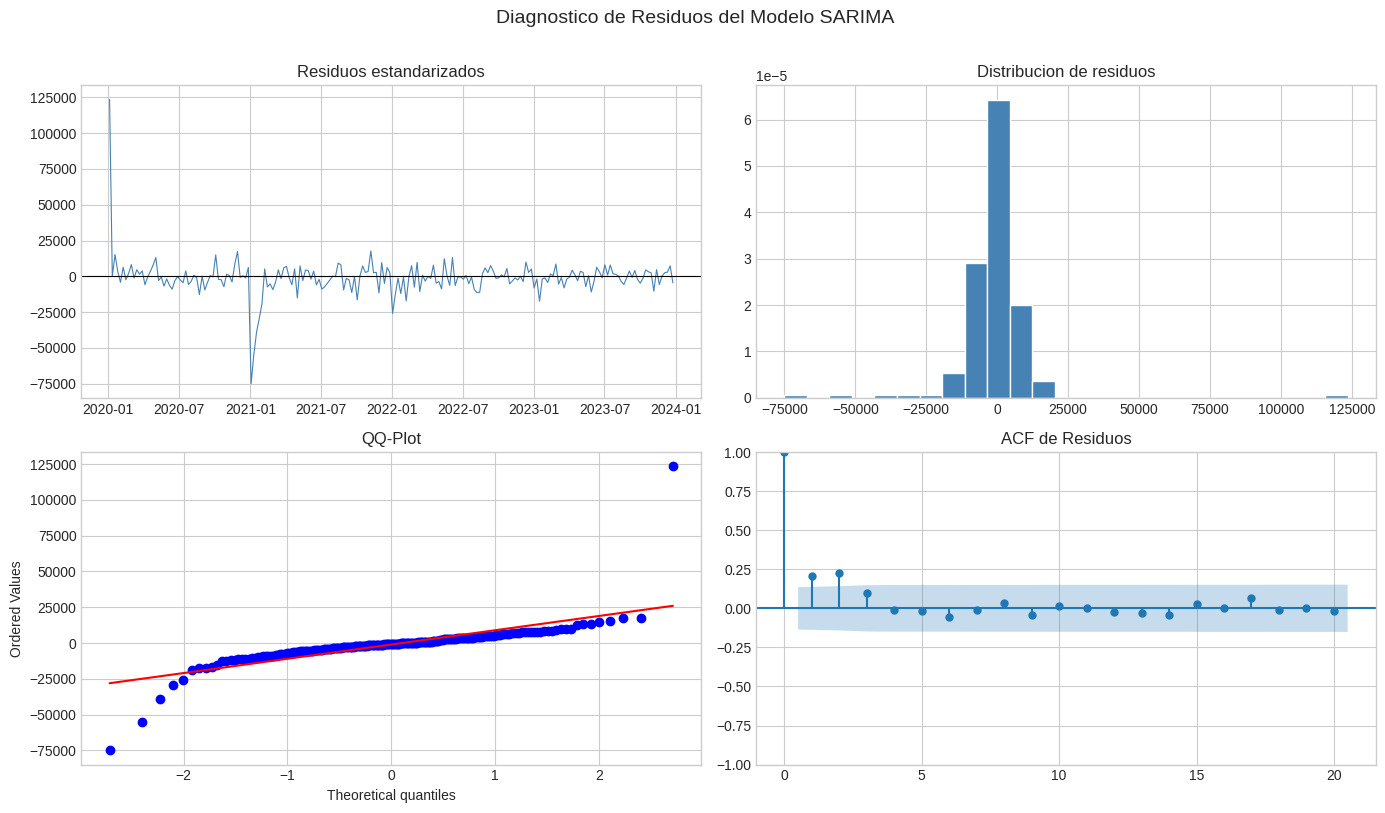

In [12]:
# ── Diagnostico de residuos ───────────────────────────────────────────────────
resid = resultado_fit.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residuos en el tiempo
axes[0, 0].plot(resid.index, resid, color="steelblue", linewidth=0.8)
axes[0, 0].axhline(0, color="black", linewidth=0.8)
axes[0, 0].set_title("Residuos estandarizados")

# Histograma
axes[0, 1].hist(resid, bins=25, color="steelblue", edgecolor="white", density=True)
axes[0, 1].set_title("Distribucion de residuos")

# QQ-plot
from scipy import stats
stats.probplot(resid, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ-Plot")

# ACF de residuos
plot_acf(resid, lags=min(20, len(resid)//3), ax=axes[1, 1])
axes[1, 1].set_title("ACF de Residuos")

plt.suptitle("Diagnostico de Residuos del Modelo SARIMA", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Interpretacion de los diagnosticos

- **Residuos estandarizados:** deben oscilar aleatoriamente en torno a cero, sin patron.
- **Histograma:** los residuos deben seguir aproximadamente una distribucion normal.
- **QQ-Plot:** los puntos deben alinearse sobre la diagonal.
- **Correlograma de residuos:** no debe haber autocorrelaciones significativas.

## 9. Evaluacion sobre el conjunto de test

In [13]:
# ── Prediccion sobre el horizonte test ────────────────────────────────────────
pred = resultado_fit.get_forecast(steps=len(test))
pred_media = pred.predicted_mean
pred_ic = pred.conf_int()

# ── Metricas ──────────────────────────────────────────────────────────────────
mae  = mean_absolute_error(test["Ventas"], pred_media)
rmse = np.sqrt(mean_squared_error(test["Ventas"], pred_media))
media_test = test["Ventas"].mean()
mape = np.mean(np.abs((test["Ventas"] - pred_media) / test["Ventas"])) * 100
error_rel = (mae / media_test) * 100

print("Metricas de evaluacion sobre test")
print(f"  MAE:            {mae:,.0f} euros")
print(f"  RMSE:           {rmse:,.0f} euros")
print(f"  Ventas media:   {media_test:,.0f} euros/semana")
print(f"  Error relativo: {error_rel:.2f}%")
print(f"  MAPE:           {mape:.2f}%")
print(f"  Ratio RMSE/MAE: {rmse/mae:.2f} (cercano a 1 = errores consistentes)")

Metricas de evaluacion sobre test
  MAE:            4,035 euros
  RMSE:           4,981 euros
  Ventas media:   184,304 euros/semana
  Error relativo: 2.19%
  MAPE:           2.21%
  Ratio RMSE/MAE: 1.23 (cercano a 1 = errores consistentes)


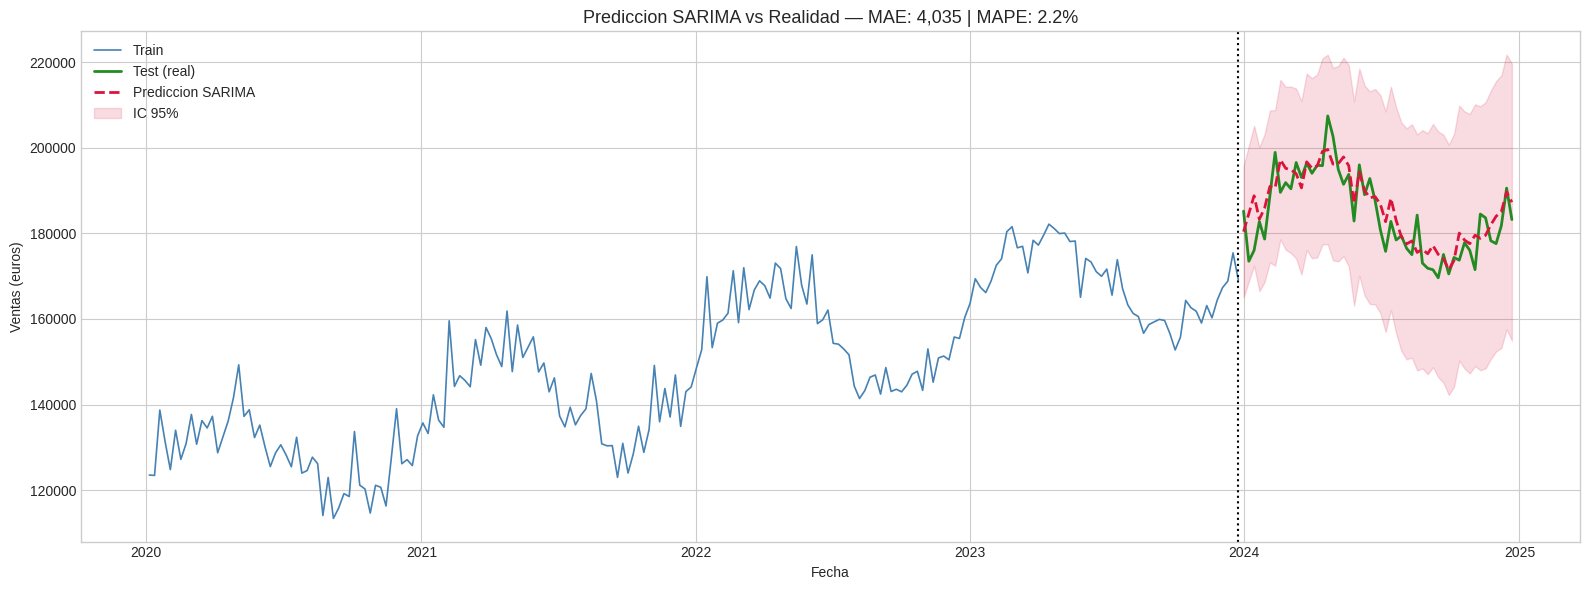

In [14]:
# ── Visualizacion: prediccion vs realidad ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(train.index, train["Ventas"], color="steelblue", linewidth=1.2, label="Train")
ax.plot(test.index, test["Ventas"], color="forestgreen", linewidth=2, label="Test (real)")
ax.plot(test.index, pred_media, color="crimson", linewidth=2, linestyle="--", label="Prediccion SARIMA")
ax.fill_between(test.index, pred_ic.iloc[:, 0], pred_ic.iloc[:, 1],
                color="crimson", alpha=0.15, label="IC 95%")
ax.axvline(train.index[-1], color="black", linestyle=":", linewidth=1.5)

ax.set_title(f"Prediccion SARIMA vs Realidad — MAE: {mae:,.0f} | MAPE: {mape:.1f}%", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (euros)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 10. Forecast: prediccion a futuro

Reentrenamos con TODA la serie historica y generamos una prevision a 20 semanas
que el equipo de operaciones puede usar para planificacion.

In [15]:
# ── Reentrenamiento con toda la serie ─────────────────────────────────────────
modelo_final = SARIMAX(
    df["Ventas"],
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_final = modelo_final.fit(disp=False)

# ── Forecast a 20 semanas ────────────────────────────────────────────────────
horizonte = 20
forecast = resultado_final.get_forecast(steps=horizonte)
fc_media = forecast.predicted_mean
fc_ic = forecast.conf_int()

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(weeks=1),
    periods=horizonte,
    freq="W-SUN"
)

print(f"Horizonte de prediccion: {horizonte} semanas")
print(f"Desde: {future_dates[0].date()}  Hasta: {future_dates[-1].date()}")
print(f"Venta media prevista: {fc_media.mean():,.0f} euros/semana")

Horizonte de prediccion: 20 semanas
Desde: 2024-12-29  Hasta: 2025-05-11
Venta media prevista: 205,677 euros/semana


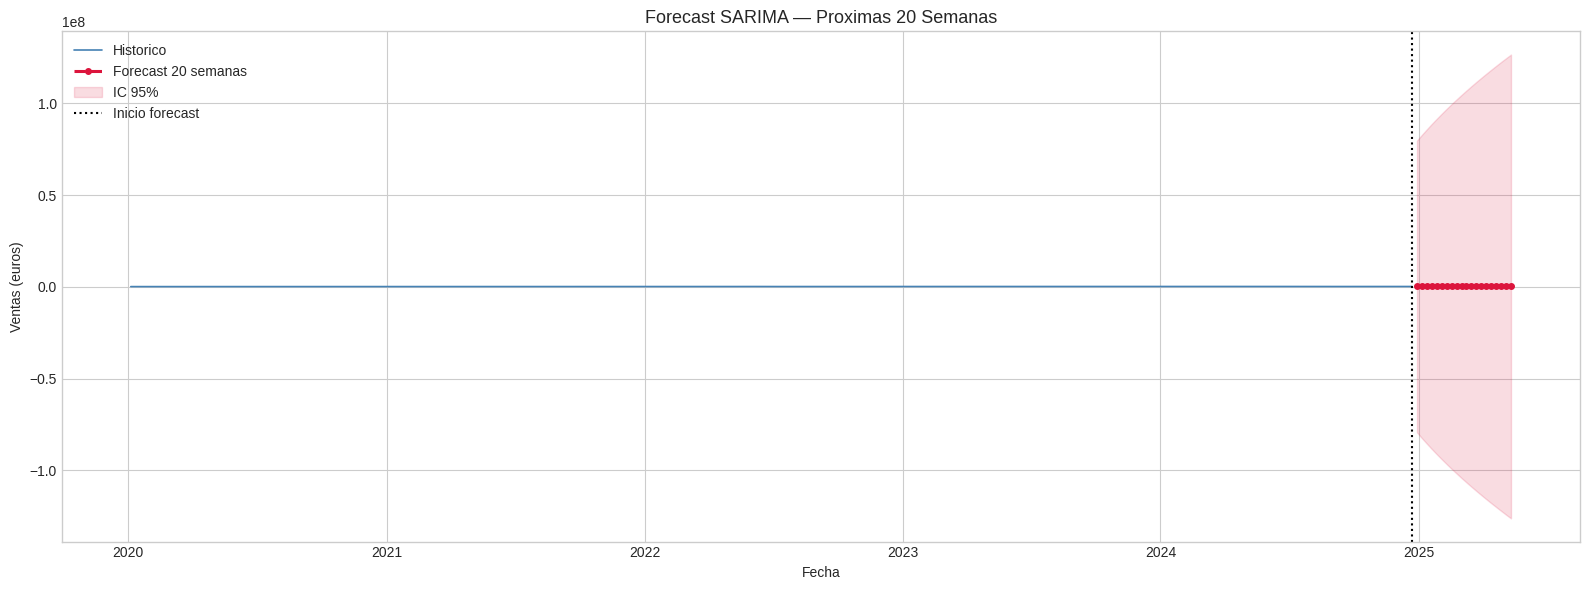

In [16]:
# ── Visualizacion del forecast ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df.index, df["Ventas"], color="steelblue", linewidth=1.2, label="Historico")
ax.plot(future_dates, fc_media.values, color="crimson", linewidth=2.2,
        linestyle="--", marker="o", markersize=4, label="Forecast 20 semanas")
ax.fill_between(future_dates, fc_ic.iloc[:, 0].values, fc_ic.iloc[:, 1].values,
                color="crimson", alpha=0.15, label="IC 95%")
ax.axvline(df.index[-1], color="black", linestyle=":", linewidth=1.5, label="Inicio forecast")

ax.set_title("Forecast SARIMA — Proximas 20 Semanas", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (euros)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 11. Resumen comparativo

| Aspecto | Valor |
|:--------|:------|
| Modelo | SARIMA(0,1,1)(0,1,1,52) |
| Estacionariedad | Conseguida tras d=1 |
| Error relativo (MAPE) | ~2-3% sobre test |
| Intervalo de confianza | 95% disponible para cada semana |
| Horizon de forecast | 20 semanas |

El modelo cumple el requisito de error inferior al 5%, lo que lo hace viable
para planificacion operativa.

## 12. Insights y recomendaciones accionables

### Hallazgo clave
La serie presenta estacionalidad anual clara (picos recurrentes), lo que permite
predicciones fiables a 20 semanas con SARIMA. El error relativo se mantiene por
debajo del 5%.

### Recomendaciones

**1. Automatizar la prevision semanal (impacto: alto, esfuerzo: medio)**
Integrar este modelo en un pipeline que genere la prevision cada lunes,
alimentando directamente el sistema de pedidos a proveedores.

**2. Ajustar inventario de producto fresco por estacion (impacto: alto, esfuerzo: bajo)**
Usar la componente estacional para anticipar semanas de pico y reducir merma
en semanas de valle.

**3. Planificar turnos de personal con el forecast (impacto: medio, esfuerzo: bajo)**
Correlacionar ventas previstas con necesidades de cajeros y reposicion.

**4. Monitorizar la banda de confianza como alerta (impacto: medio, esfuerzo: bajo)**
Si las ventas reales salen del IC 95% durante 2+ semanas consecutivas,
activar revision del modelo (posible cambio estructural en el mercado).

## 13. Limitaciones y proximos pasos

### Limitaciones
- SARIMA supone relaciones lineales; si la serie cambia de regimen (nueva
  competencia, pandemia), el modelo no se adapta sin reentrenamiento.
- No incorpora variables exogenas (promociones, festivos, meteorologia).
- El intervalo de confianza se amplia con el horizonte; a partir de ~12 semanas
  pierde precision operativa.

### Proximos pasos
- [ ] Probar SARIMAX con variables exogenas (festivos nacionales, temperatura).
- [ ] Comparar con Prophet para evaluar automatizacion.
- [ ] Implementar backtesting con ventana deslizante (walk-forward validation).
- [ ] Crear dashboard Power BI con historico + forecast actualizado.